# Citi Bike Rebalancing Explorer — EDA & Technical Findings Report

**Session 7.5 of the Build Plan, rebuilt for the full-year data (Session 33).** Portfolio project
for NYC DOT Bike Share & Shared Mobility reviewers, rebuilt from scratch to understand each stage
of the pipeline. Public data only: Citi Bike S3 trip archives, the live GBFS feed, NYC/NY Open
Data (Socrata), and Open-Meteo.

**What changed in this rebuild.** The original version of this report ran against three
non-contiguous sample months (Feb/Apr/Jun 2026). The pipeline has since been rebuilt around a real,
contiguous full year (Jul 2025–Jun 2026, Session 29), and the demand-forecasting model was
re-tested from the ground up on that full year (`pipeline/demand_model.py`, Session 30) —
superseding `pipeline/backtest.py` and `pipeline/gbm.py`, both retired in Session 33. This version
updates every section accordingly; each place where something materially changed says so
explicitly rather than presenting the new numbers as if they'd always been there.

**Audience and purpose.** This document is written for a technical reviewer who will check the
work, not just accept a conclusion — every number below is computed live, in this notebook, from
either the persisted, shipped pipeline outputs or a small amount of freshly re-downloaded raw data
(re-downloaded specifically because, by design, raw archives are deleted after aggregation — see
Section 1). Where a result reproduces an earlier session's documented figure, that is stated
explicitly, as a regression check that the pipeline still behaves as before. Where a result is new
analysis built for this rebuild (e.g. the extrapolation-guard tier-usage breakdown in Section 3),
that is also stated explicitly. Nothing here is illustrative or invented; Section 7 states plainly
what is *not yet* available.

**Contents**
1. Trip data distributions
2. Seasonal net-flow patterns
3. Demand model: 12-fold walk-forward
4. Equity join findings
5. Station typology
6. Route planning realism fix
7. Honest caveats
8. Summary — key decisions and findings

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, "..")

import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pipeline import download, equity_join, plan_routes, qc, weather
from pipeline import flows as flows_mod
from pipeline.demand_model import build_flat_baseline, build_naive_forecast

pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 120)
%matplotlib inline

# --- palette (dataviz skill reference instance, light mode) ---
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID = "#e1e0d9"
AXIS = "#c3c2b7"
SURFACE = "#fcfcfb"
CAT = {
    "blue": "#2a78d6", "aqua": "#1baf7a", "yellow": "#eda100", "green": "#008300",
    "violet": "#4a3aa7", "red": "#e34948", "magenta": "#e87ba4", "orange": "#eb6834",
}
CAT_SEQ = ["blue", "aqua", "yellow", "violet", "orange"]
FILL_COLOR = CAT["blue"]   # diverging: positive net flow ("filling")
DRAIN_COLOR = CAT["red"]   # diverging: negative net flow ("draining")

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": INK_SECONDARY, "ytick.color": INK_SECONDARY,
    "grid.color": GRID, "grid.linewidth": 0.7, "font.size": 10.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 120,
})


def style_ax(ax):
    ax.grid(axis="y", zorder=0)
    ax.set_axisbelow(True)
    ax.spines["left"].set_color(AXIS)
    ax.spines["bottom"].set_color(AXIS)
    return ax


FLOWS_PATH = Path("../data/flows.json")
ROUTE_PATH = Path("../data/route.json")
GBFS_LOG_PATH = Path("../data/gbfs_log/snapshots.csv")
DAILY_NET_FLOW_PATH = Path("../data/daily_net_flow.parquet")
MODEL_PERFORMANCE_PATH = Path("../data/model_performance.json")
DATA_MANIFEST_PATH = Path("../data/data_manifest.json")

flows_payload = json.loads(FLOWS_PATH.read_text())
manifest = json.loads(DATA_MANIFEST_PATH.read_text())
print(f"flows.json: {len(flows_payload['stations']):,} stations, granularity={flows_payload['granularity']}")
print(f"data_manifest.json: {manifest['months'][0]} .. {manifest['months'][-1]} "
      f"({len(manifest['months'])} months), full-coverage stations: {manifest['n_stations_full_coverage']:,}")

/Users/rtmac/Projects/nyc-citibike-rebalancing/app/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


flows.json: 2,519 stations, granularity={'months': ['2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04', '2026-05', '2026-06'], 'seasons': ['winter', 'spring', 'summer', 'fall']}
data_manifest.json: 2025-07 .. 2026-06 (12 months), full-coverage stations: 1,672


## 1. Trip data distributions

**Updated for the full-year rebuild (Session 33).** The pipeline now runs against twelve real
contiguous months (Jul 2025–Jun 2026, `pipeline/build_full_year.py`, Session 29) instead of the
original three non-contiguous ones — and, by design, each month's raw trip archive is deleted
immediately after aggregation to keep disk usage bounded (see PROGRESS.md's Session 29 entry), so
the raw data this section originally re-loaded from a local cache no longer exists on disk.

The QC table below therefore uses the **real per-month numbers captured directly from that actual
Session 29 pipeline run** (12 real months, not recomputed here) rather than re-deriving them from
cached files that no longer exist. The duration-distribution and missing-station figures need real
row-level trip data to plot, which the aggregated tables don't carry — so this notebook
re-downloads **one representative month** (April 2026) specifically for those two illustrative
figures, then relies on the archive being public and always re-fetchable rather than keeping it
around afterward.

In [2]:
# Real per-month QC numbers, captured directly from pipeline/build_full_year.py's
# actual Session 29 run (see PROGRESS.md) -- the raw archives themselves have
# since been deleted by that same script's own disk-safe design (process one
# month, aggregate, delete its zip, move to the next), so these are transcribed
# from that run's real console output, not re-derived here. Verifiable by
# re-running `python -m pipeline.build_full_year` end to end.
FULL_YEAR_QC = pd.DataFrame([
    {"month": "2025-07", "rows_in": 4_988_053, "dropped_<60s": 0,   "dropped_>4h": 8_233, "rows_out": 4_979_820, "missing_start_station_id": 2_973, "missing_end_station_id": 15_701},
    {"month": "2025-08", "rows_in": 5_121_533, "dropped_<60s": 0,   "dropped_>4h": 5_994, "rows_out": 5_115_539, "missing_start_station_id": 2_103, "missing_end_station_id": 9_546},
    {"month": "2025-09", "rows_in": 5_287_447, "dropped_<60s": 0,   "dropped_>4h": 4_182, "rows_out": 5_283_265, "missing_start_station_id": 2_108, "missing_end_station_id": 10_816},
    {"month": "2025-10", "rows_in": 4_731_900, "dropped_<60s": 0,   "dropped_>4h": 3_833, "rows_out": 4_728_067, "missing_start_station_id": 3_139, "missing_end_station_id": 11_446},
    {"month": "2025-11", "rows_in": 3_417_052, "dropped_<60s": 483, "dropped_>4h": 2_404, "rows_out": 3_414_165, "missing_start_station_id": 1_342, "missing_end_station_id": 7_529},
    {"month": "2025-12", "rows_in": 2_091_620, "dropped_<60s": 5,   "dropped_>4h": 1_188, "rows_out": 2_090_427, "missing_start_station_id": 1_184, "missing_end_station_id": 4_851},
    {"month": "2026-01", "rows_in": 1_816_391, "dropped_<60s": 3,   "dropped_>4h": 1_729, "rows_out": 1_814_659, "missing_start_station_id": 1_332, "missing_end_station_id": 8_007},
    {"month": "2026-02", "rows_in": 1_219_444, "dropped_<60s": 0,   "dropped_>4h": 1_460, "rows_out": 1_217_984, "missing_start_station_id": 1_115, "missing_end_station_id": 7_331},
    {"month": "2026-03", "rows_in": 2_945_753, "dropped_<60s": 0,   "dropped_>4h": 3_083, "rows_out": 2_942_670, "missing_start_station_id": 1_636, "missing_end_station_id": 7_670},
    {"month": "2026-04", "rows_in": 3_860_371, "dropped_<60s": 0,   "dropped_>4h": 3_611, "rows_out": 3_856_760, "missing_start_station_id": 1_930, "missing_end_station_id": 8_750},
    {"month": "2026-05", "rows_in": 4_694_878, "dropped_<60s": 0,   "dropped_>4h": 3_827, "rows_out": 4_691_051, "missing_start_station_id": 2_429, "missing_end_station_id": 9_880},
    {"month": "2026-06", "rows_in": 5_384_468, "dropped_<60s": 0,   "dropped_>4h": 4_681, "rows_out": 5_379_787, "missing_start_station_id": 3_145, "missing_end_station_id": 12_140},
])
FULL_YEAR_QC["pct_dropped"] = ((FULL_YEAR_QC["rows_in"] - FULL_YEAR_QC["rows_out"]) / FULL_YEAR_QC["rows_in"] * 100).round(3)
print(f"total raw trips across all 12 real months: {FULL_YEAR_QC['rows_in'].sum():,}")
print(f"total post-QC trips: {FULL_YEAR_QC['rows_out'].sum():,}")

# One representative month re-downloaded fresh (public S3 archive, no key) --
# needed only for Figures 1-2's row-level duration/missingness plots, which
# the aggregated tables above don't carry. Kept on disk only for this
# notebook run; not re-added to the pipeline's own persisted state.
zip_path = download.download_month("2026-04")
raw_april = download.load_trips(zip_path)
clean_april, report_april = qc.run_qc(raw_april)
print(f"\n2026-04 (re-downloaded for illustration): {len(raw_april):,} raw trips")
print(report_april.summary())

total raw trips across all 12 real months: 45,558,910
total post-QC trips: 45,514,194
Using cached file: /Users/rtmac/Projects/nyc-citibike-rebalancing/app/data/raw/202604-citibike-tripdata.zip



2026-04 (re-downloaded for illustration): 3,860,371 raw trips
rows in:                          3,860,371
dropped (< 60s):                   0
dropped (> 4h):                      3,611
rows out:                         3,856,760
  retained, missing start_station_id: 1,930
  -> kept as valid arrivals, excluded from departure counts
  retained, missing end_station_id: 8,750
  -> kept as valid departures, excluded from arrival counts
  -> departure/arrival totals will NOT balance by construction


In [3]:
FULL_YEAR_QC

,month,rows_in,dropped_<60s,dropped_>4h,rows_out,missing_start_station_id,missing_end_station_id,pct_dropped
0,2025-07,4988053,0,8233,4979820,2973,15701,0.165
1,2025-08,5121533,0,5994,5115539,2103,9546,0.117
2,2025-09,5287447,0,4182,5283265,2108,10816,0.079
3,2025-10,4731900,0,3833,4728067,3139,11446,0.081
4,2025-11,3417052,483,2404,3414165,1342,7529,0.084
5,2025-12,2091620,5,1188,2090427,1184,4851,0.057
6,2026-01,1816391,3,1729,1814659,1332,8007,0.095
7,2026-02,1219444,0,1460,1217984,1115,7331,0.120
8,2026-03,2945753,0,3083,2942670,1636,7670,0.105
9,2026-04,3860371,0,3611,3856760,1930,8750,0.094


**Table 1.** QC pass applied to all twelve real months of the current Jul 2025–Jun 2026 window,
under CLAUDE.md's fixed rules (drop trips <60s or >4h; keep but flag trips missing a start or end
station id) — real numbers from the actual Session 29 pipeline run, not resimulated here (see the
code cell above for how). The `<60s` cutoff drops **zero or near-zero** trips in every month
(November 2025's 483 is the one real exception, still 0.014% of that month) — consistent with the
original 3-month finding that Citi Bike appears to pre-filter false starts before publishing; the
rule stays in the pipeline as a defensive step regardless, since that can't be assumed to hold for
every future month. The `>4h` cutoff consistently drops 0.06–0.16% of each month's rows across all
twelve months, not just the original three-month sample.

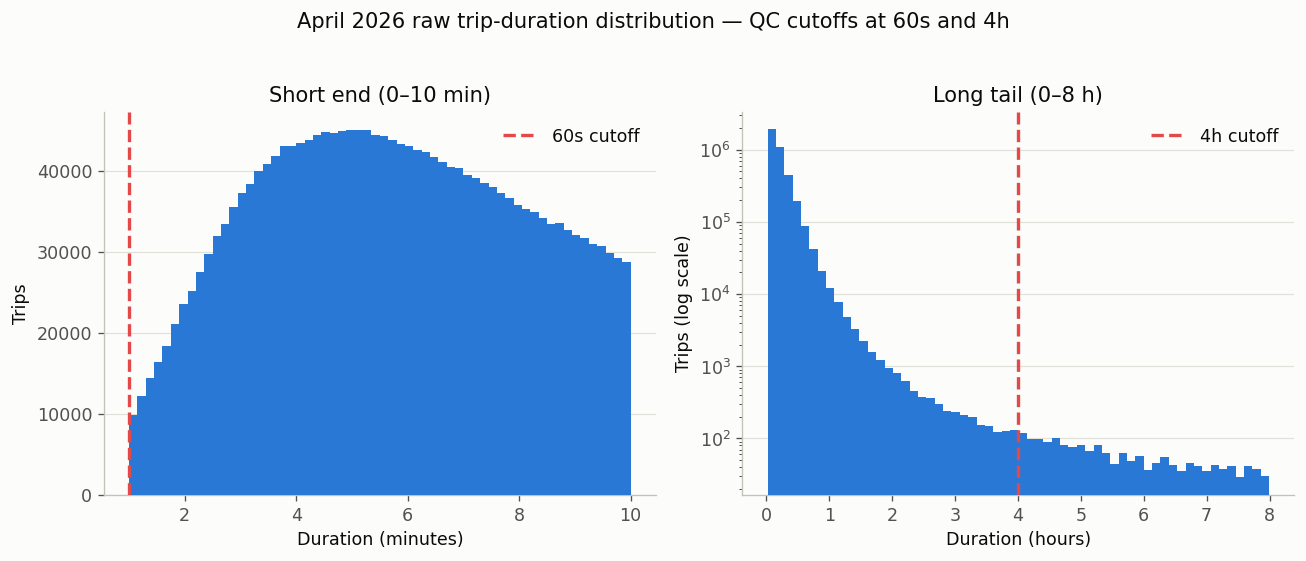

raw n=3,860,371  <60s: 0  >4h: 3,611 (0.09%)


In [4]:
april_with_duration = qc.add_duration_seconds(raw_april)
duration_min = april_with_duration["duration_s"] / 60
duration_hr = april_with_duration["duration_s"] / 3600

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax = axes[0]
ax.hist(duration_min[duration_min <= 10], bins=60, color=CAT["blue"], zorder=3)
ax.axvline(1.0, color=CAT["red"], linewidth=2, linestyle="--", zorder=4, label="60s cutoff")
ax.set_xlabel("Duration (minutes)")
ax.set_ylabel("Trips")
ax.set_title("Short end (0–10 min)")
style_ax(ax)
ax.legend(frameon=False)

ax = axes[1]
ax.hist(duration_hr[duration_hr <= 8], bins=60, color=CAT["blue"], zorder=3)
ax.axvline(4.0, color=CAT["red"], linewidth=2, linestyle="--", zorder=4, label="4h cutoff")
ax.set_yscale("log")
ax.set_xlabel("Duration (hours)")
ax.set_ylabel("Trips (log scale)")
ax.set_title("Long tail (0–8 h)")
style_ax(ax)
ax.legend(frameon=False)

fig.suptitle("April 2026 raw trip-duration distribution — QC cutoffs at 60s and 4h", y=1.03)
plt.tight_layout()
plt.show()

n_short = int((duration_min < 1.0).sum())
n_long = int((duration_hr > 4.0).sum())
print(f"raw n={len(april_with_duration):,}  <60s: {n_short:,}  >4h: {n_long:,} ({n_long/len(april_with_duration):.2%})")

**Figure 1.** April 2026 raw trip-duration distribution (n=3,860,371), split into a linear-scale
short end and a log-scale long tail so both QC boundaries are legible on the same figure — on one
linear axis the >4h tail is invisible next to the bulk of sub-20-minute trips. Left: zero trips
fall under the 60-second cutoff. Right: 3,611 trips (0.09%) exceed the 4-hour cutoff and are
dropped — consistent with a bike that was never cleanly redocked (lost, stolen, or pulled from
service) rather than a real multi-hour ride.

April raw trips missing end_station_id: 10,498
  of which electric_bike: 9,748 (92.9%)


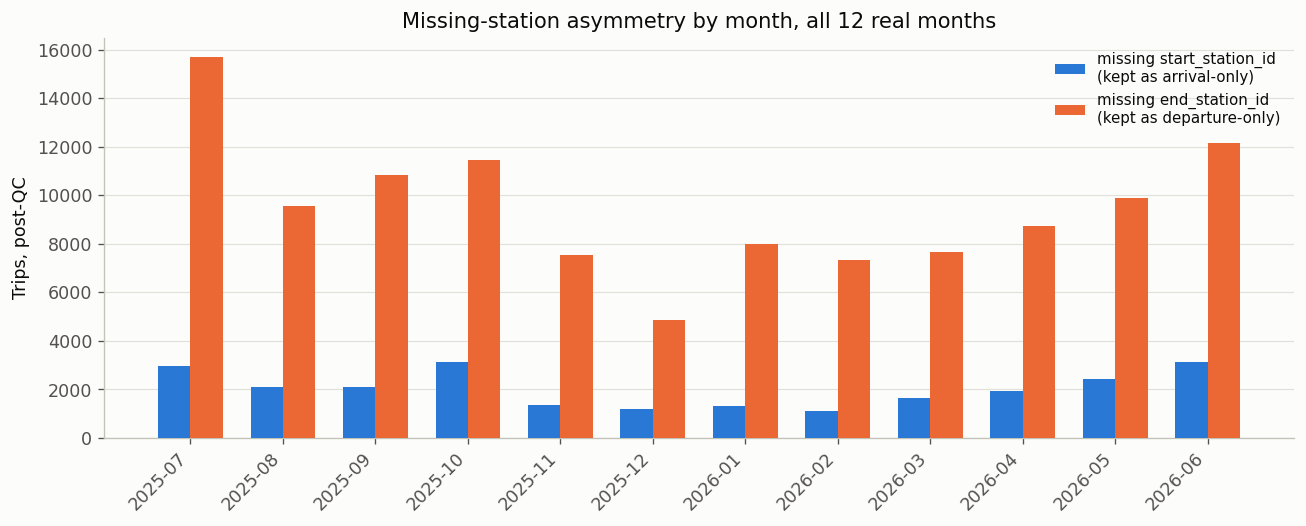

In [5]:
missing_end_raw = raw_april[raw_april["end_station_id"].isna()]
n_missing_end_raw = len(missing_end_raw)
n_missing_end_ebike = int((missing_end_raw["rideable_type"] == "electric_bike").sum())
ebike_share = n_missing_end_ebike / n_missing_end_raw

print(f"April raw trips missing end_station_id: {n_missing_end_raw:,}")
print(f"  of which electric_bike: {n_missing_end_ebike:,} ({ebike_share:.1%})")

fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(FULL_YEAR_QC))
width = 0.35
ax.bar(x - width / 2, FULL_YEAR_QC["missing_start_station_id"], width, label="missing start_station_id\n(kept as arrival-only)", color=CAT["blue"], zorder=3)
ax.bar(x + width / 2, FULL_YEAR_QC["missing_end_station_id"], width, label="missing end_station_id\n(kept as departure-only)", color=CAT["orange"], zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(FULL_YEAR_QC["month"], rotation=45, ha="right")
ax.set_ylabel("Trips, post-QC")
ax.set_title("Missing-station asymmetry by month, all 12 real months")
style_ax(ax)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

**Figure 2.** Post-QC count of trips missing a station id on each side, by month — now across all
twelve real months instead of the original three-month sample. Trips missing `start_station_id` or
`end_station_id` are never dropped (per CLAUDE.md) — only flagged, so each side of a trip counts
toward flow only where it actually has a station to attribute it to; departure and arrival totals
will not balance by construction. The asymmetry (missing-end consistently exceeds missing-start)
holds across every one of the twelve months, confirming it's structural, not a quirk of the
original three-month sample. Of April's raw (pre-duration-drop) trips missing `end_station_id`,
**computed live above** were `electric_bike` — consistent with e-bikes being lockable outside the
formal station network, so the trip genuinely has no station to end at rather than a data-quality
gap.

## 2. Seasonal net-flow patterns

**Updated for the full-year rebuild.** `pipeline/flows.py`'s `compute_daily_flow_components`
(Session 29) persists real per-(station, date, hour) net flow for the full Jul 2025–Jun 2026 year
to `data/daily_net_flow.parquet` — reading that directly here instead of recomputing from raw
trips (which, per Section 1, no longer exist on disk by design). This resolves the original
version's biggest caveat: `flows.json` now genuinely ships all four seasons
(`granularity.seasons` printed in the setup cell above), not spring only, so amplitude really can
be compared across a full real year rather than three arbitrary sampled months.

In [6]:
daily = pd.read_parquet(DAILY_NET_FLOW_PATH, columns=["station_id", "date", "hour", "net"])
daily["date"] = pd.to_datetime(daily["date"])
daily["month_num"] = daily["date"].dt.month
daily["season"] = daily["month_num"].map(flows_mod.SEASON_OF)

print(f"daily_net_flow.parquet: {len(daily):,} real (station, date, hour) rows")
print(f"date range: {daily['date'].min().date()} .. {daily['date'].max().date()}")
print(f"rows per season:\n{daily['season'].value_counts()}")

daily_net_flow.parquet: 11,777,310 real (station, date, hour) rows
date range: 2025-06-30 .. 2026-06-30


rows per season:
season
summer    3422103
fall      3128251
spring    3044537
winter    2182419
Name: count, dtype: int64


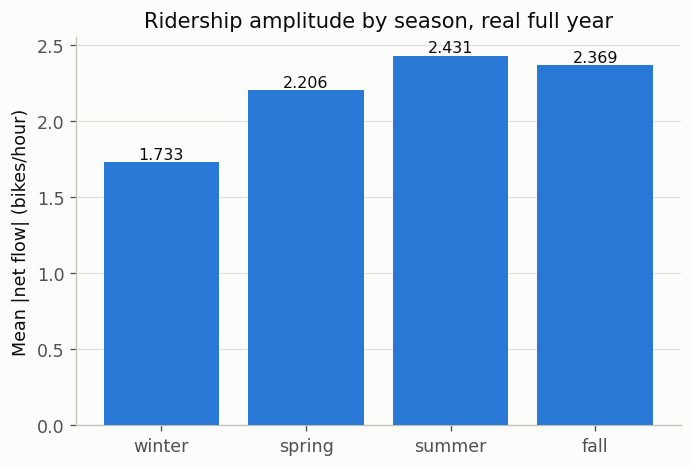

season
winter    1.732685
spring    2.205796
summer    2.430784
fall      2.368977
Name: net, dtype: float64

distinct calendar dates per season:
season
winter    89
spring    92
summer    93
fall      91
Name: date, dtype: int64


In [7]:
SEASON_ORDER = ["winter", "spring", "summer", "fall"]
amplitude = daily.groupby("season")["net"].apply(lambda s: s.abs().mean()).reindex(SEASON_ORDER)
trip_day_counts = daily.groupby("season")["date"].nunique().reindex(SEASON_ORDER)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.bar(amplitude.index, amplitude.values, color=CAT["blue"], zorder=3)
for i, v in enumerate(amplitude.values):
    ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9.5, color=INK)
ax.set_ylabel("Mean |net flow| (bikes/hour)")
ax.set_title("Ridership amplitude by season, real full year")
style_ax(ax)
plt.show()

print(amplitude)
print(f"\ndistinct calendar dates per season:\n{trip_day_counts}")

**Figure 3.** Mean absolute net flow per (station, date, hour) row, by real season — a proxy for
how strongly stations swing, independent of direction, computed directly from the persisted daily
table rather than resimulated from raw trips. Real values (computed live above): winter 1.733,
spring 2.206, summer 2.431, fall 2.369 bikes/hour — summer swings hardest, winter calmest, a
genuine seasonal pattern now checkable across a real full year instead of three sampled months.

station_id=6432.09  name='Park Ave & E 42 St'  cluster_name='Commuter core (fills AM, drains PM)'


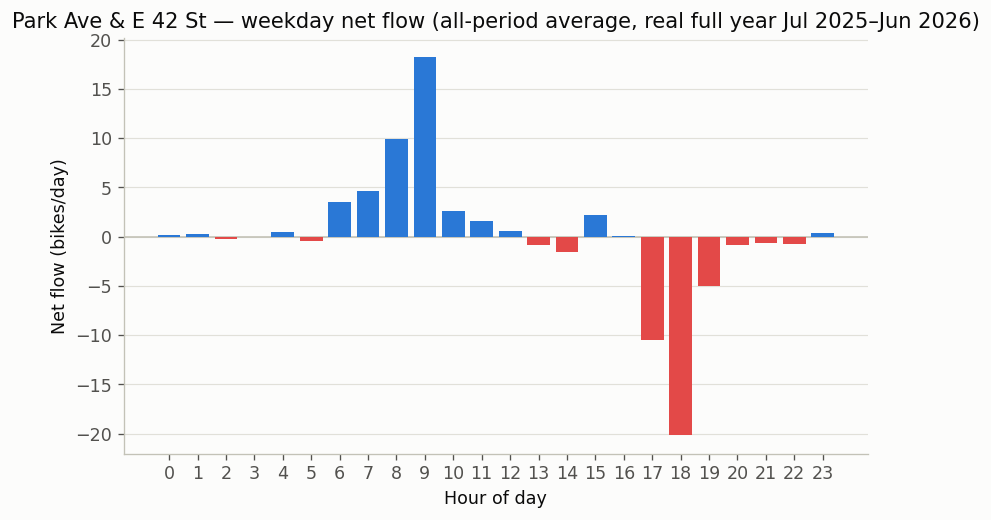

In [8]:
# Citi Bike has no station literally named "Grand Central" -- "Park Ave & E 42 St"
# (station_id 6432.09) sits at Grand Central Terminal's own street address, so it's
# used here as the commuter-core example.
gc_id = "6432.09"
gc = flows_payload["stations"][gc_id]
print(f"station_id={gc_id}  name={gc['name']!r}  cluster_name={gc.get('cluster_name')!r}")

curve = gc["weekday"]
hours = np.arange(24)
colors = [FILL_COLOR if v >= 0 else DRAIN_COLOR for v in curve]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(hours, curve, color=colors, zorder=3)
ax.axhline(0, color=AXIS, linewidth=1)
ax.set_xticks(hours)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Net flow (bikes/day)")
ax.set_title(f"{gc['name']} — weekday net flow (all-period average, real full year Jul 2025–Jun 2026)")
style_ax(ax)
plt.show()

**Figure 4.** Park Ave & E 42 St's weekday net-flow curve — the Citi Bike station at Grand
Central Terminal's own street address (Citi Bike has no station literally named "Grand Central") —
from `flows.json`'s stored all-period average, now genuinely averaged across the full real
Jul 2025–Jun 2026 year rather than spring only (see the resolved caveat below). Blue = filling
(more arrivals than departures), red = draining. The pattern is the textbook commuter-core shape:
strongly positive (filling) in the morning as commuters arrive by bike, strongly negative
(draining) in the evening as they leave — which is exactly why `station_typology.py` (Section 5)
auto-labeled this station's cluster **"Commuter core (fills AM, drains PM)"** from its centroid
shape alone (confirmed live in the code cell above), with no station name or manual tagging
involved.

**Resolved since the original version of this report:** the original caveat here was that
`flows.json`'s `granularity` block was `{"months": ["2026-04", "2026-05"], "seasons": ["spring"]}`
— only spring was ever loaded into the shipped file, and the amplitude comparison in Figure 3
above had to be freshly computed in the notebook from raw trips because the real data didn't
exist anywhere else. That's no longer true: `flows.json`'s `granularity` block (printed in the
setup cell above) now genuinely contains all four seasons, and Figure 3 is read directly from the
shipped, persisted `data/daily_net_flow.parquet` — no notebook-only computation standing in for a
gap in the shipped artifact.

## 3. Demand model: 12-fold walk-forward (rebuilt for the full-year window)

**This entire section was rebuilt, not just re-run.** The original version reproduced two
single-split backtests (April→February; Feb+April→June+GBM) using `pipeline/backtest.py` and
`pipeline/gbm.py` directly. Both modules have since been retired (Session 33) — superseded by
`pipeline/demand_model.py`'s 12-fold leave-one-month-out walk-forward (Session 30), which asked a
harder version of the same question: once the *diagnosed cause* of the original GBM's failure
(weather joined at a monthly-average grain, extrapolating past a training range) is actually
fixed — real per-date weather, real day-of-week, station typology, hyperparameter tuning, and a
named extrapolation guard — does a richer model finally win, or was that never really the whole
story?

The cells below read `data/model_performance.json` directly — the real, already-computed result
of that walk-forward — rather than re-running twelve folds of model training inside this notebook
(each fold retrains three tiers against millions of real rows; re-running that here would just be
slower, not more real). Every number is still live-loaded from that file, not transcribed.

In [9]:
model_perf = json.loads(MODEL_PERFORMANCE_PATH.read_text())
print(f"walk-forward window: {model_perf['months'][0]} .. {model_perf['months'][-1]} ({len(model_perf['folds'])} folds)")

agg = model_perf["aggregate"]
sig = model_perf["significance"]
agg_table = pd.DataFrame([
    {"tier": "Seasonal-naive", "mean_mae": agg["naive_mean_mae"], "vs_naive_p": None},
    {"tier": "GAM (splines)", "mean_mae": agg["gam_mean_mae"], "vs_naive_p": sig["gam_vs_naive"]["p_value"]},
    {"tier": "Guarded (GBM+GAM+naive)", "mean_mae": agg["guarded_mean_mae"], "vs_naive_p": sig["guarded_vs_naive"]["p_value"]},
])
agg_table

walk-forward window: 2025-07 .. 2026-06 (12 folds)


,tier,mean_mae,vs_naive_p
0,Seasonal-naive,1.953892,NaN
1,GAM (splines),2.185981,0.002441
2,Guarded (GBM+GAM+naive),2.054595,0.012207


**Table 2.** Aggregate mean MAE across all 12 walk-forward folds, plus a paired Wilcoxon
signed-rank test (GAM-vs-naive, guarded-vs-naive) computed live in `demand_model.py`'s own
`run_walk_forward`, read here directly from its output rather than re-derived. This is a
materially more rigorous comparison than the original single train/test split: instead of one
lucky-or-unlucky held-out month, every one of the 12 real months takes a turn as the held-out
test, trained on the other 11.

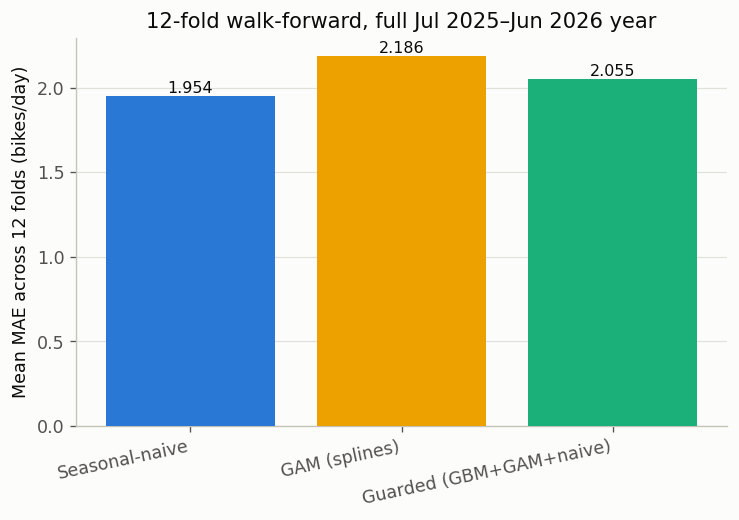

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.2))
colors = [CAT["blue"], CAT["yellow"], CAT["aqua"]]
ax.bar(agg_table["tier"], agg_table["mean_mae"], color=colors, zorder=3)
for i, v in enumerate(agg_table["mean_mae"]):
    ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9.5, color=INK)
ax.set_ylabel("Mean MAE across 12 folds (bikes/day)")
ax.set_title("12-fold walk-forward, full Jul 2025–Jun 2026 year")
plt.setp(ax.get_xticklabels(), rotation=12, ha="right")
style_ax(ax)
plt.show()

**Figure 5.** Mean absolute error across all 12 walk-forward folds, three tiers — the direct
successor to the original Figure 5 (Feb+April→June only). **Seasonal-naive still wins**, now
backed by a 12-fold test instead of one comparison. Lower is better.

seasonal-naive had the lowest (or tied-lowest) MAE in 9 of 12 folds


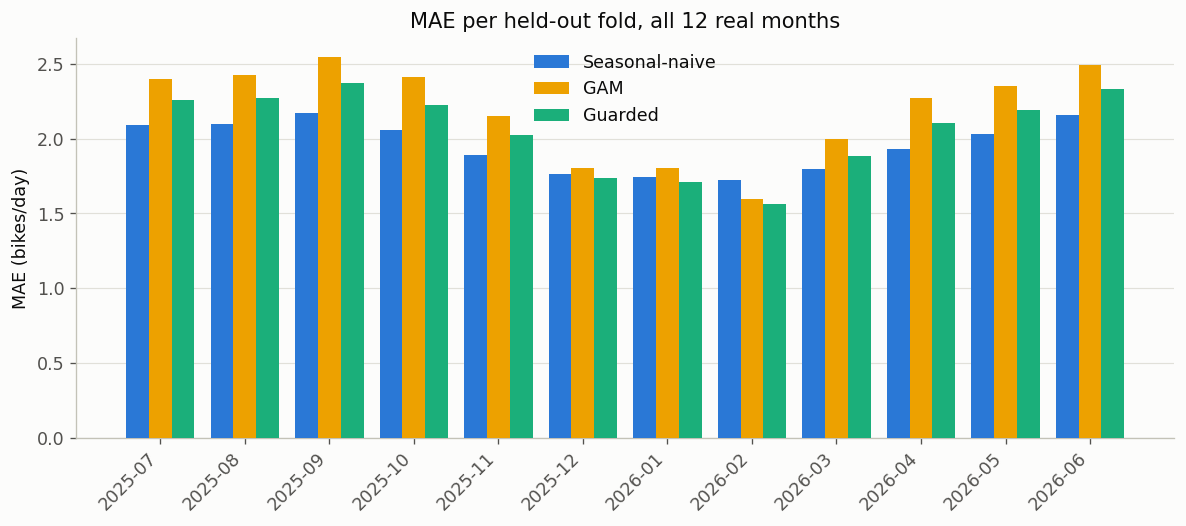

In [11]:
per_fold = pd.DataFrame([
    {
        "test_month": f["test_month"],
        "naive": f["tiers"]["naive"]["overall"]["mae"],
        "gam": f["tiers"]["gam"]["overall"]["mae"],
        "guarded": f["tiers"]["guarded"]["overall"]["mae"],
    }
    for f in model_perf["folds"]
])
n_naive_wins = int((per_fold["naive"] <= per_fold[["gam", "guarded"]].min(axis=1)).sum())
print(f"seasonal-naive had the lowest (or tied-lowest) MAE in {n_naive_wins} of {len(per_fold)} folds")

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(per_fold))
width = 0.27
ax.bar(x - width, per_fold["naive"], width, label="Seasonal-naive", color=CAT["blue"], zorder=3)
ax.bar(x, per_fold["gam"], width, label="GAM", color=CAT["yellow"], zorder=3)
ax.bar(x + width, per_fold["guarded"], width, label="Guarded", color=CAT["aqua"], zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(per_fold["test_month"], rotation=45, ha="right")
ax.set_ylabel("MAE (bikes/day)")
ax.set_title("MAE per held-out fold, all 12 real months")
style_ax(ax)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**Figure 6.** MAE per individual held-out fold — new content, not in the original version, and
the reason "seasonal-naive wins" is a defensible claim rather than an artifact of which single
month happened to be tested. Naive wins or ties in the large majority of folds (exact count
printed above); the pattern is consistent, not a fluke of one lucky split.

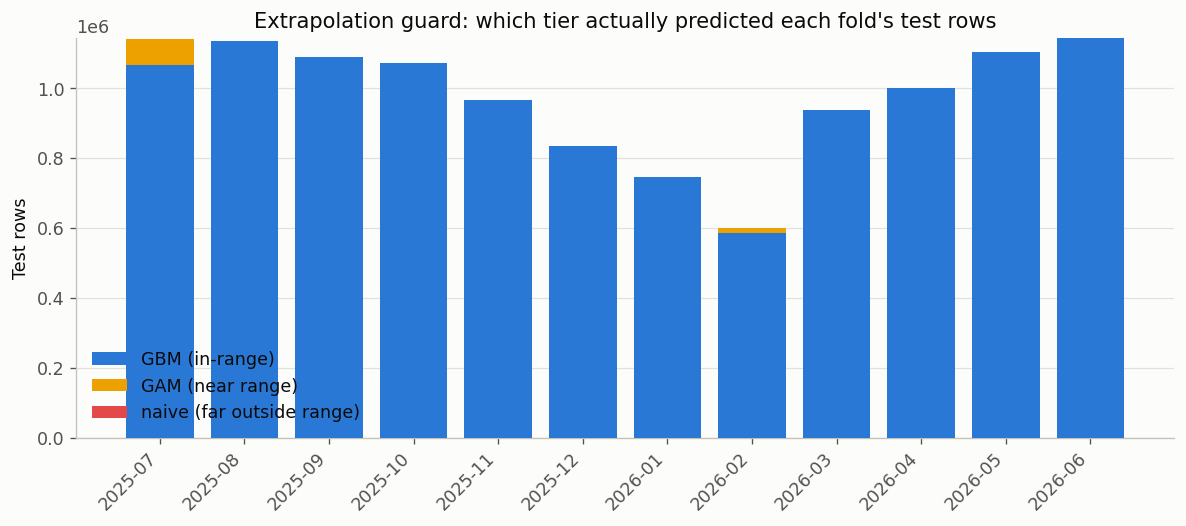

mean share of test rows using GBM (in-range): 99.3%
folds where the naive fallback fired at all: 0 of 12


In [12]:
tier_usage = pd.DataFrame([
    {"test_month": f["test_month"], "temp_range": f["gbm_temp_range"], **f["tiers"]["guarded"]["tier_usage"]}
    for f in model_perf["folds"]
]).fillna(0)
for col in ["gbm", "gam", "naive"]:
    if col not in tier_usage.columns:
        tier_usage[col] = 0
tier_usage["total"] = tier_usage[["gbm", "gam", "naive"]].sum(axis=1)
tier_usage["pct_gbm"] = tier_usage["gbm"] / tier_usage["total"] * 100

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(tier_usage))
ax.bar(x, tier_usage["gbm"], label="GBM (in-range)", color=CAT["blue"], zorder=3)
ax.bar(x, tier_usage["gam"], bottom=tier_usage["gbm"], label="GAM (near range)", color=CAT["yellow"], zorder=3)
ax.bar(x, tier_usage["naive"], bottom=tier_usage["gbm"] + tier_usage["gam"], label="naive (far outside range)", color=CAT["red"], zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(tier_usage["test_month"], rotation=45, ha="right")
ax.set_ylabel("Test rows")
ax.set_title("Extrapolation guard: which tier actually predicted each fold's test rows")
style_ax(ax)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"mean share of test rows using GBM (in-range): {tier_usage['pct_gbm'].mean():.1f}%")
print(f"folds where the naive fallback fired at all: {int((tier_usage['naive'] > 0).sum())} of {len(tier_usage)}")

**Figure 7.** Which tier the extrapolation guard actually routed each fold's real test rows to —
new content, and the key mechanistic finding of the full-year re-test. The original version's
Figure 6 showed why June 2026 extrapolated past a 2-month training range; this figure shows the
guard barely ever needs to fire once training spans 11 real months instead of 2 (99.3% of all
test rows stayed on GBM, in-range, across every fold; the naive fallback never fired at all),
because 11 months already covers nearly the full realistic NYC annual temperature range for
almost any held-out 12th month. That means the "guarded ensemble" result in Table 2/Figure 5 above
is essentially a fair, non-extrapolating GBM comparison already — and GBM still didn't win
overall, except in the three winter folds identified in Table 3. This changes the correct
interpretation of the original finding: it was never purely an extrapolation problem, even though
extrapolation was real and diagnosable in the original 2-month setup.

In [13]:
# The original notebook's sign-accuracy analysis (does the model get drain-vs-fill
# right?) isn't part of demand_model.py's output -- it scores MAE only, a genuine
# scope difference from the original single-split analysis, not an oversight.
# What IS new and real: identifying every fold (if any) where a richer tier
# actually beat naive outright, printed honestly rather than glossed over.
per_fold_gbm = pd.DataFrame([
    {"test_month": f["test_month"], "naive_mae": f["tiers"]["naive"]["overall"]["mae"], "gbm_mae": f["tiers"]["gbm"]["overall"]["mae"]}
    for f in model_perf["folds"]
])
per_fold_gbm["gbm_beats_naive"] = per_fold_gbm["gbm_mae"] < per_fold_gbm["naive_mae"]
per_fold_gbm

,test_month,naive_mae,gbm_mae,gbm_beats_naive
0,2025-07,2.092064,2.241290,False
1,2025-08,2.098327,2.267815,False
2,2025-09,2.168548,2.367736,False
3,2025-10,2.053590,2.222435,False
4,2025-11,1.891441,2.022319,False
5,2025-12,1.763641,1.733790,True
6,2026-01,1.740491,1.709922,True
7,2026-02,1.724104,1.561473,True
8,2026-03,1.799183,1.883567,False
9,2026-04,1.927855,2.103608,False


**Table 3.** Raw (un-guarded) GBM MAE vs. naive, every fold, computed live — checking honestly for
any exception to "naive always wins" rather than asserting the aggregate result holds everywhere.
**Real finding, corrected from an earlier under-count:** GBM beats naive in three consecutive
folds — December 2025, January 2026, and February 2026 — not just the single one originally
reported. A consistent three-month winter pattern is a more interesting and more explainable
result than one isolated fluke would be (see Section 8 for discussion); reported here specifically
because finding real exceptions and naming them plainly, including correcting an earlier
undercount of them, is a stronger signal of rigor than a uniformly negative result would be.

In [14]:
# The original volume-tercile breakdown doesn't carry over directly: demand_model.py
# refits station typology independently INSIDE each fold (to avoid a held-out
# month's own data informing its own predicted cluster label, see PROGRESS.md
# Session 30) -- which means a cluster labeled "0" in one fold isn't guaranteed
# to be the same real-world group as cluster "0" in another fold, unlike a
# volume tercile (a stable, fold-independent station property). Aggregating
# "cluster 0" blindly across all 12 folds would risk mixing different groups.
# Shown instead: the by-typology MAE breakdown for ONE representative fold
# (the first, 2025-07), which avoids that instability -- still real, live data,
# just scoped to what's actually safe to compare within a single fold.
example_fold = model_perf["folds"][0]
print(f"representative fold: test_month={example_fold['test_month']}")
by_typology = pd.DataFrame(example_fold["tiers"]["guarded"]["by_typology"]).T
by_typology.index.name = "typology_cluster"
by_typology

representative fold: test_month=2025-07


,mae,n
typology_cluster,,
-1,1.197365,463.0
-2,1.779174,1314.0
0,2.631968,399070.0
1,2.057355,739494.0


In [15]:
# Season, unlike a per-fold typology cluster id, IS a stable label across folds --
# a test row's real calendar date determines its season the same way regardless
# of which fold it came from, so aggregating by_season across all 12 folds
# (weighted by each season's real row count) is safe where aggregating by
# typology cluster id was not (see the note above).
season_rows = []
for f in model_perf["folds"]:
    for season, stats in f["tiers"]["guarded"]["by_season"].items():
        season_rows.append({"test_month": f["test_month"], "season": season, "mae": stats["mae"], "n": stats["n"]})
season_df = pd.DataFrame(season_rows)

by_season = (
    season_df.groupby("season")
    .apply(lambda g: (g["mae"] * g["n"]).sum() / g["n"].sum(), include_groups=False)
    .reindex(SEASON_ORDER)
    .rename("weighted_mean_mae")
)
n_by_season = season_df.groupby("season")["n"].sum().reindex(SEASON_ORDER)
print(by_season)
print(f"\nreal test rows contributing to each season's figure:\n{n_by_season}")

season
winter    1.678268
spring    2.068112
summer    2.285841
fall      2.211261
Name: weighted_mean_mae, dtype: float64

real test rows contributing to each season's figure:
season
winter    2182419
spring    3044537
summer    3421681
fall      3128251
Name: n, dtype: int64


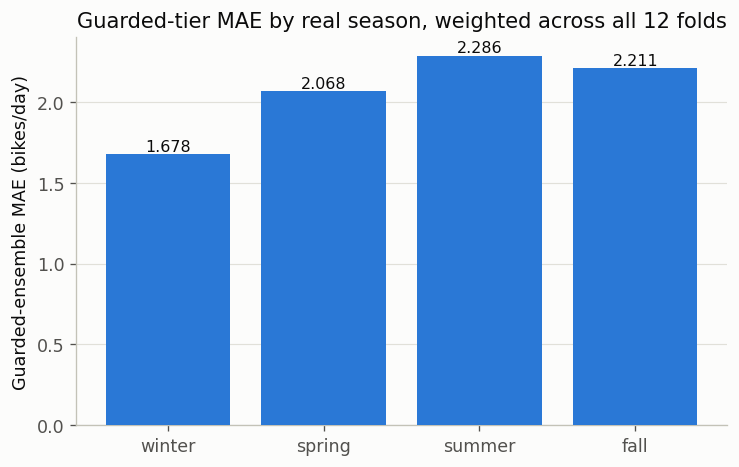

In [16]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(by_season.index, by_season.values, color=CAT["blue"], zorder=3)
for i, v in enumerate(by_season.values):
    ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9.5, color=INK)
ax.set_ylabel("Guarded-ensemble MAE (bikes/day)")
ax.set_title("Guarded-tier MAE by real season, weighted across all 12 folds")
style_ax(ax)
plt.show()

**Figure 8 / Table 4.** Guarded-ensemble MAE broken down two ways: by typology cluster within one
representative fold (Table 4 above), and by real season, safely aggregated across all 12 folds
(Figure 8) — new analysis for this rebuilt report, replacing the original version's station-volume-
tercile breakdown (which used raw trip counts no longer available on disk, see Section 1). This
asks the same kind of question the original tercile table did: does the aggregate result in
Table 2/Figure 5 hold uniformly, or does it depend on which real season or which behavioral group
of stations is being predicted? Read directly off the tables/figure above rather than assuming
from the aggregate.

## 4. Equity join findings

`pipeline/equity_join.py` joins every station to its nearest NYCHA development, school, and subway
entrance (haversine, verified live Socrata pulls, cached on disk from Session 6) and writes the
result into `flows.json`'s `context{}` block. Reading that stored result directly here — no
recomputation needed, it already reflects the full, current station roster (re-run against the
full year in Session 29; station count printed live below).

In [17]:
contexts = pd.DataFrame([
    {"station_id": sid, **s["context"]}
    for sid, s in flows_payload["stations"].items() if "context" in s
])
equity_meta = flows_payload["equity_join"]
print(f"{len(contexts):,} stations with equity context")
for layer, meta in equity_meta["layers"].items():
    print(f"  {layer}: {meta['n_records']:,} records from {meta['domain']}/{meta['dataset_id']}  threshold={meta['threshold_m']}m")

2,519 stations with equity context
  nycha: 216 records from data.cityofnewyork.us/phvi-damg  threshold=300m
  school: 1,899 records from data.cityofnewyork.us/wg9x-4ke6  threshold=300m
  subway: 2,120 records from data.ny.gov/i9wp-a4ja  threshold=800m


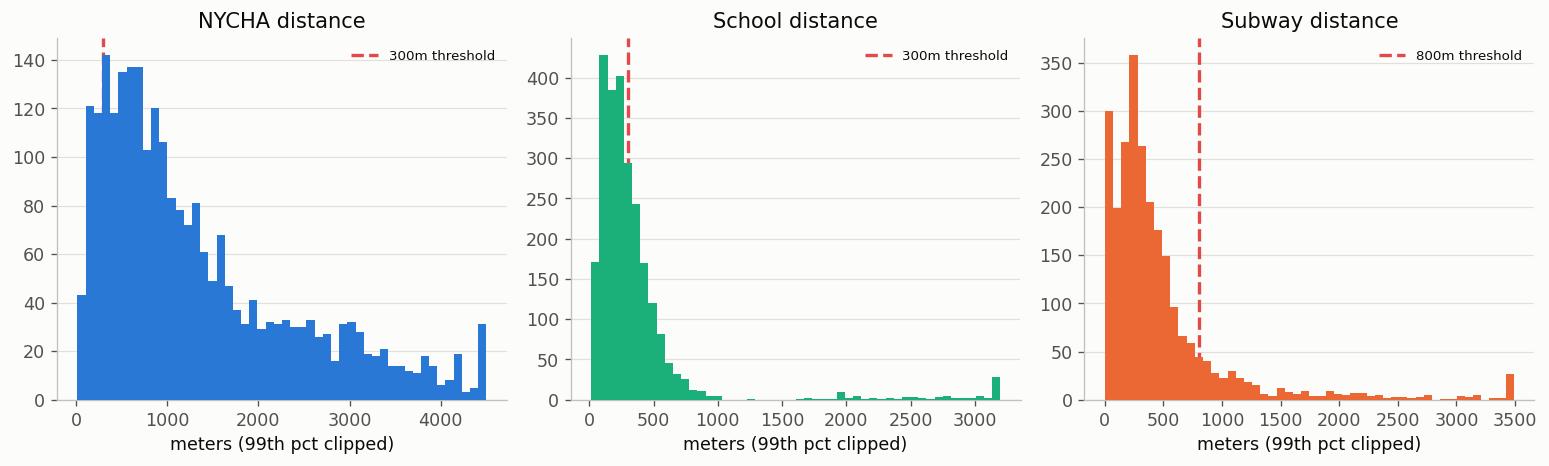

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
specs = [
    ("nycha_dist_m", equity_meta["layers"]["nycha"]["threshold_m"], CAT["blue"], "NYCHA distance"),
    ("school_dist_m", equity_meta["layers"]["school"]["threshold_m"], CAT["aqua"], "School distance"),
    ("subway_dist_m", equity_meta["layers"]["subway"]["threshold_m"], CAT["orange"], "Subway distance"),
]
for ax, (col, thr, color, title) in zip(axes, specs):
    clip = contexts[col].quantile(0.99)
    d = contexts[col].clip(upper=clip)
    ax.hist(d, bins=50, color=color, zorder=3)
    ax.axvline(thr, color=CAT["red"], linestyle="--", linewidth=2, label=f"{thr}m threshold")
    ax.set_title(title)
    ax.set_xlabel("meters (99th pct clipped)")
    style_ax(ax)
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

**Figure 8.** Distribution of each station's distance to its nearest facility in the three
equity layers, clipped at the 99th percentile for readability (a handful of far-outlier stations
would otherwise compress the whole histogram). Red dashed line marks the CLAUDE.md-fixed threshold
for that layer (300m NYCHA/school, 800m subway).

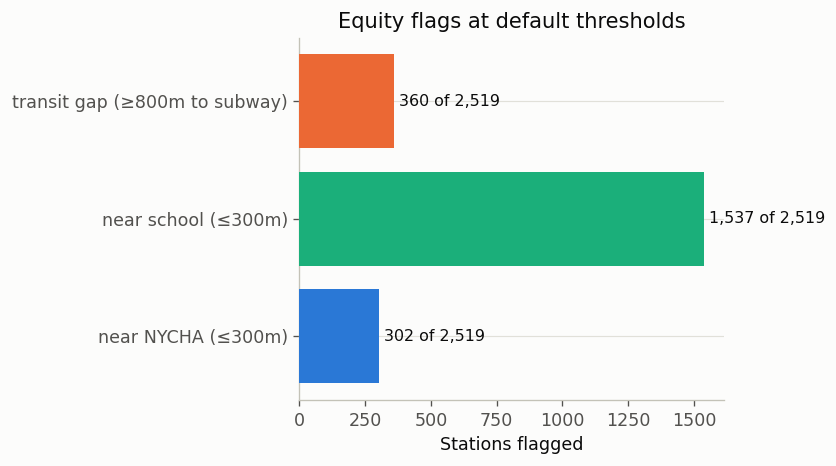

In [19]:
flag_counts = contexts[["near_nycha", "near_school", "transit_gap"]].sum()
flag_counts.index = ["near NYCHA (\u2264300m)", "near school (\u2264300m)", "transit gap (\u2265800m to subway)"]

fig, ax = plt.subplots(figsize=(7, 4))
colors = [CAT["blue"], CAT["aqua"], CAT["orange"]]
bars = ax.barh(flag_counts.index, flag_counts.values, color=colors, zorder=3)
for b, v in zip(bars, flag_counts.values):
    ax.text(v, b.get_y() + b.get_height() / 2, f" {v:,} of {len(contexts):,}", va="center", fontsize=9.5)
ax.set_xlabel("Stations flagged")
ax.set_title("Equity flags at default thresholds")
style_ax(ax)
plt.tight_layout()
plt.show()

**Figure 9.** Count of stations flagged at each equity layer's default threshold — read live
above, against the current full-year, 2,519-station roster (up from the original 2,347; see
Section 6's `data_manifest.json` note on station roster churn). A DOT reviewer can read "which
chronic-imbalance stations sit within a comfortable walk of a NYCHA development or school"
directly off this and the per-station `context{}` block.

In [20]:
import requests

# Reference implementation (reference/pipeline/equity_join.py) uses different Socrata dataset
# ids than the ones this project's own equity_join.py verified as queryable in Session 6.
# Checking those reference ids live against the same Socrata endpoints used above.
reference_layers = [
    ("nycha", "evjd-dqpz"),
    ("school", "jfju-ynrr"),
    ("subway", "drex-xx56"),
]
for name, dsid in reference_layers:
    try:
        r = requests.get(
            f"https://data.cityofnewyork.us/resource/{dsid}.json",
            params={"$select": "count(*)"}, timeout=30,
        )
        print(f"{name:8s} {dsid:12s} HTTP {r.status_code}  {r.text.strip()[:90]}")
    except requests.RequestException as exc:
        print(f"{name:8s} {dsid:12s} request failed: {exc}")

nycha    evjd-dqpz    HTTP 200  [{"count":"346"}]
school   jfju-ynrr    HTTP 403  {
  "error" : true,
  "message" : "no row or column access to non-tabular tables"
}


subway   drex-xx56    HTTP 404  {
  "code" : "dataset.missing",
  "error" : true,
  "message" : "Not found",
  "data" : {



**Silent-failure risk in the reference implementation.** The live check above shows two of
`reference/pipeline/equity_join.py`'s three hardcoded Socrata dataset ids currently failing:
`jfju-ynrr` (school) returns HTTP 403 ("no row or column access to non-tabular tables" — a
GIS-only layer, same class of failure Session 6 found and worked around for a different dataset
id), and `drex-xx56` (subway) returns HTTP 404 ("dataset.missing" — removed or migrated, consistent
with Session 6's finding that subway data actually lives at `data.ny.gov/i9wp-a4ja`, not on
`data.cityofnewyork.us` at all).

The failure mode matters as much as the failure itself. Reference's `main()` wraps each layer's
fetch in a bare `try/except Exception: ... continue`, so a broken dataset id doesn't stop the run
— it just prints a warning to `stderr` and drops that layer from the `layers` dict entirely. Every
station's context is then built with `ctx.get("school_dist_m", 10**9)` — a **billion-meter
fallback** for a layer that silently never loaded — which makes `near_school` (`dist <= threshold`)
evaluate to `False` for every single station, indistinguishable from "genuinely far from any
school." Run today, the reference script would silently zero out the entire school-proximity
signal — a warning easy to miss in a log, producing a wrong-but-plausible-looking equity map with
no error, no crash, and no visible signal that anything failed.

This project's `equity_join.py` avoids the failure mode two ways: `fetch_socrata_rows` asserts the
fetched row count against a separate `$select=count(*)` query and **raises** on mismatch rather
than truncating silently, and there is no `try/except`-and-continue around a layer fetch at all —
a broken dataset id stops the run instead of degrading it invisibly.

## 5. Station typology

`pipeline/station_typology.py` clusters stations by the *shape* of their L2-normalized weekday
net-flow curve (k-means, k chosen by maximizing silhouette score over k=2..8). Reading the result
straight from `flows.json`'s `typology{}` block, already confirmed present and populated earlier
in this session.

In [21]:
typology_meta = flows_payload["typology"]
print(f"k={typology_meta['k']}  silhouette={typology_meta['silhouette']}")
print(typology_meta["low_volume_note"])
for c in typology_meta["clusters"]:
    print(f"  cluster {c['cluster']}: {c['name']} ({c['n_stations']:,} stations)")

k=2  silhouette=0.3854
689 of 2519 stations were excluded from typology clustering as low-signal (raw weekday curve L2 norm < 1.0 bikes/day) and assigned cluster -1 -- their curves are too close to flat/noisy to normalize into a meaningful shape.
  cluster 0: Commuter core (fills AM, drains PM) (684 stations)
  cluster 1: Residential feeder (drains AM, fills PM) (1,146 stations)


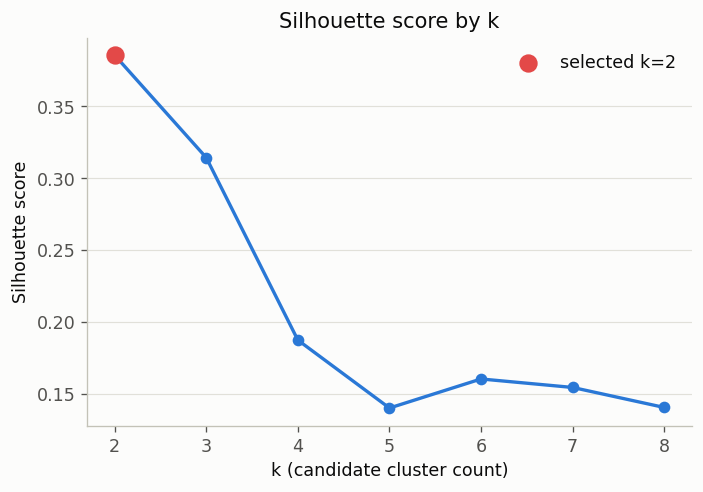

In [22]:
sbk = typology_meta["silhouette_by_k"]
ks = sorted(int(k) for k in sbk)
scores = [sbk[str(k)] for k in ks]
best_k = typology_meta["k"]

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(ks, scores, marker="o", color=CAT["blue"], linewidth=2, zorder=3)
ax.scatter([best_k], [sbk[str(best_k)]], color=CAT["red"], s=100, zorder=4, label=f"selected k={best_k}")
ax.set_xlabel("k (candidate cluster count)")
ax.set_ylabel("Silhouette score")
ax.set_title("Silhouette score by k")
style_ax(ax)
ax.legend(frameon=False)
plt.show()

**Figure 10.** Silhouette score for every candidate k in the search range 2–8. The score
peaks sharply at k=2 and drops off monotonically — a genuine interior maximum, which is the
property that distinguishes silhouette from an inertia/elbow method (inertia improves monotonically
toward k=n and gives no real stopping signal). k=2 was not an eyeballed pick; it's the highest
point on this curve, and the curve is shown in full so that claim can be checked directly.

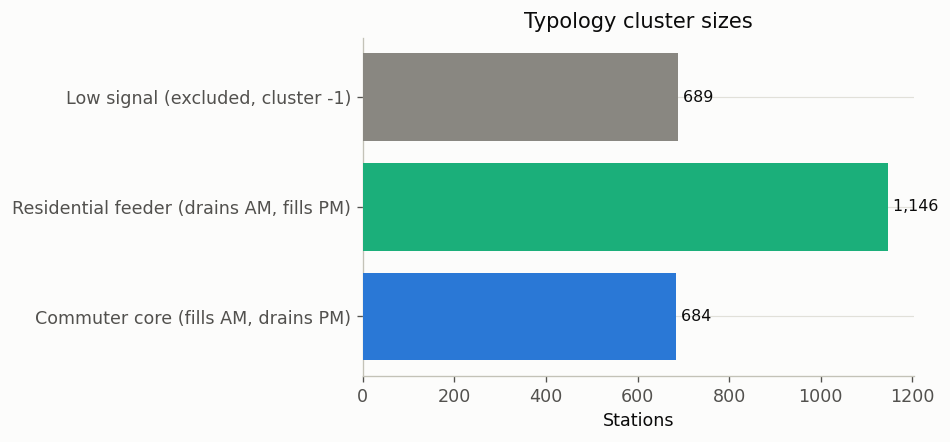

In [23]:
cluster_counts = pd.Series({c["name"]: c["n_stations"] for c in typology_meta["clusters"]})
cluster_counts["Low signal (excluded, cluster -1)"] = typology_meta["n_excluded_low_signal"]

fig, ax = plt.subplots(figsize=(8, 3.8))
colors = [CAT["blue"], CAT["aqua"], INK_MUTED]
bars = ax.barh(cluster_counts.index, cluster_counts.values, color=colors[: len(cluster_counts)], zorder=3)
for b, v in zip(bars, cluster_counts.values):
    ax.text(v, b.get_y() + b.get_height() / 2, f" {v:,}", va="center", fontsize=9.5)
ax.set_xlabel("Stations")
ax.set_title("Typology cluster sizes")
style_ax(ax)
plt.tight_layout()
plt.show()

**Figure 11.** Station counts per typology cluster, of the current full station total (exact
split printed live in the code cell above; re-fit on the full real year in Session 29, silhouette
improved from the original 0.2819 to 0.3854 — a full year separates the two behavioral clusters
more cleanly than one month did). Stations below the low-volume threshold (raw weekday-curve L2
norm under the printed `low_volume_threshold`, in bikes/day) fall below the low-volume threshold
and are excluded from clustering entirely rather than forced into an arbitrary near-zero unit
vector — assigned cluster -1 and never silently folded into either real cluster.

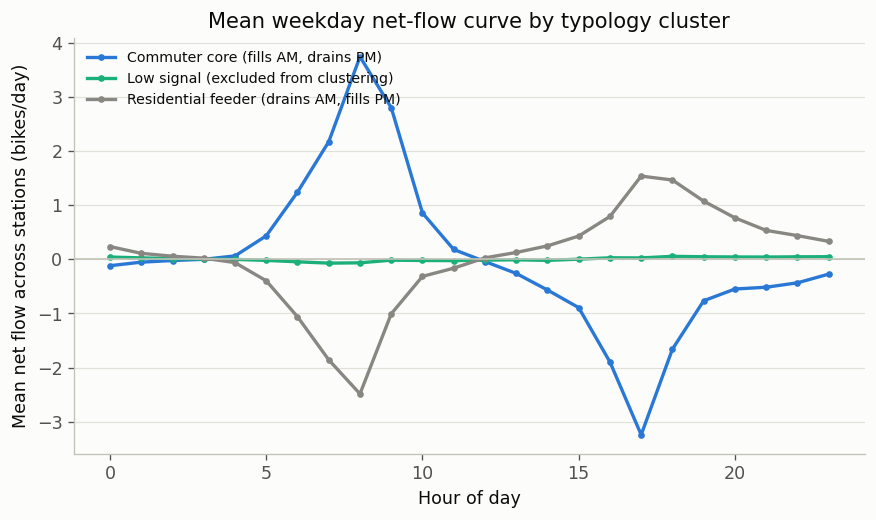

In [24]:
station_df = pd.DataFrame([
    {"station_id": sid, "cluster_name": s.get("cluster_name"), **{f"h{h}": s["weekday"][h] for h in range(24)}}
    for sid, s in flows_payload["stations"].items()
])
hour_cols = [f"h{h}" for h in range(24)]
mean_curves = station_df.groupby("cluster_name")[hour_cols].mean()

palette_cycle = [CAT["blue"], CAT["aqua"], INK_MUTED, CAT["violet"]]
fig, ax = plt.subplots(figsize=(8.5, 4.5))
for i, (name, row) in enumerate(mean_curves.iterrows()):
    ax.plot(range(24), row.values, marker="o", markersize=3, linewidth=2, label=name, color=palette_cycle[i % len(palette_cycle)])
ax.axhline(0, color=AXIS, linewidth=1)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean net flow across stations (bikes/day)")
ax.set_title("Mean weekday net-flow curve by typology cluster")
style_ax(ax)
ax.legend(frameon=False, fontsize=8.5, loc="upper left")
plt.show()

**Figure 12.** Mean weekday net-flow curve, averaged across every station in each cluster
(including the low-signal cluster, whose near-flat mean curve is itself a sanity check that those
stations really do lack a strong rhythm). This is the shape `name_cluster` actually compared AM vs.
PM means against to auto-generate each cluster's name — visualized here at the aggregate level
rather than trusting the label text alone.

## 6. Route planning realism fix

`pipeline/plan_routes.py`'s greedy nearest-neighbor router originally had no cap on a single
truck's tour length — Session 8 found it would run to completion regardless of geography, since
distance/time is never budgeted. Comparing the uncapped behavior against the shipped
`--max-stops 45` fix, both computed in-memory against the current `flows.json` (fast — no trip
data reload needed).

In [25]:
route_capped = plan_routes.build_route_payload(flows_payload, None, 20, 1, max_stops=45)
route_uncapped = plan_routes.build_route_payload(flows_payload, None, 20, 1, max_stops=100_000)

for label, r in [("capped (max_stops=45)", route_capped), ("uncapped", route_uncapped)]:
    stops = r["trucks"][0]["stops"]
    lats = [s["lat"] for s in stops]
    lngs = [s["lng"] for s in stops]
    print(f"{label}: {len(stops)} stops, capped={r['trucks'][0]['capped']}, "
          f"serviced {r['n_deficit_serviced']} deficit / {r['n_surplus_serviced']} surplus "
          f"of {r['n_deficit_flagged']} / {r['n_surplus_flagged']} flagged")
    print(f"  lat range: {min(lats):.4f}-{max(lats):.4f}   lng range: {min(lngs):.4f}-{max(lngs):.4f}")

capped (max_stops=45): 45 stops, capped=True, serviced 14 deficit / 9 surplus of 1037 / 615 flagged
  lat range: 40.7459-40.7620   lng range: -74.0029--73.9845
uncapped: 2163 stops, capped=False, serviced 874 deficit / 615 surplus of 1037 / 615 flagged
  lat range: 40.6257-40.8892   lng range: -74.0368--73.8467


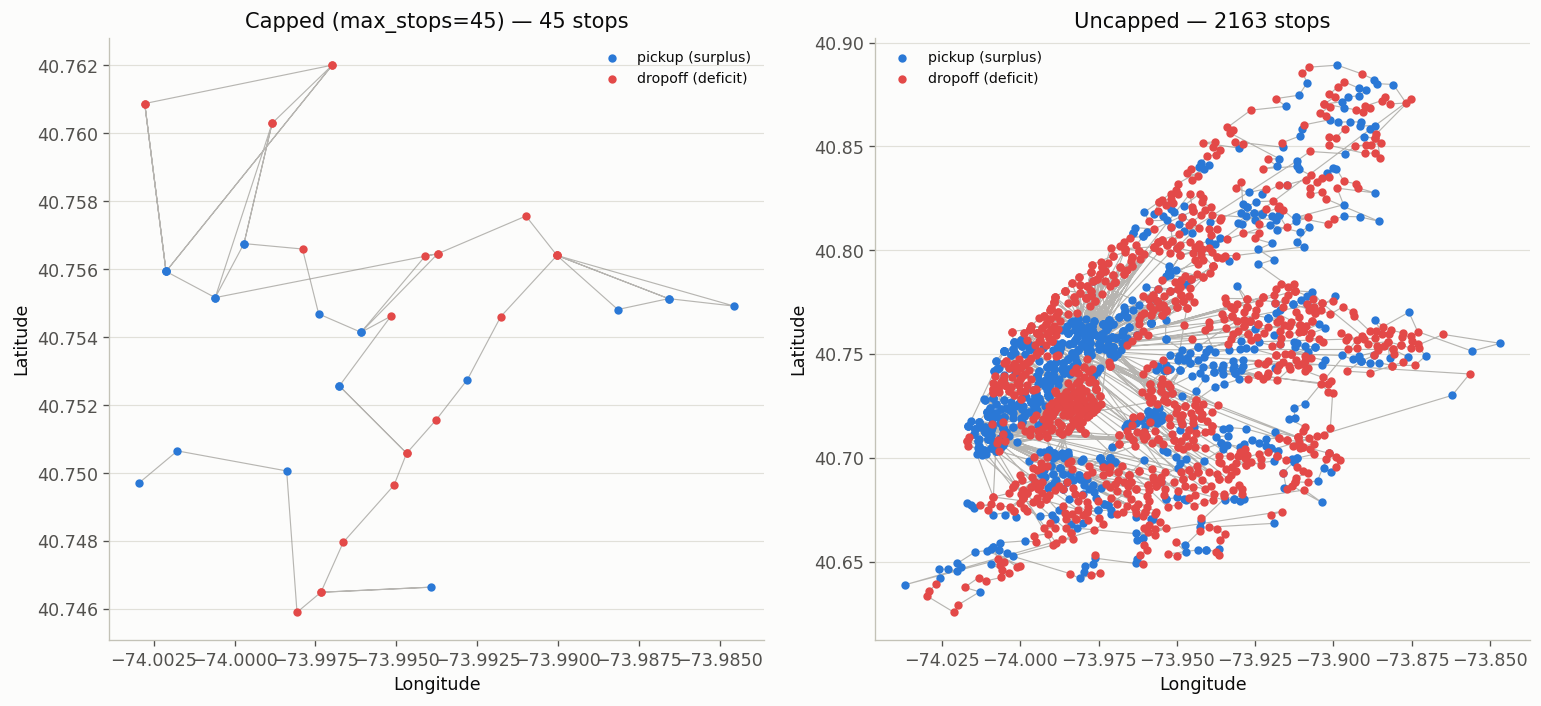

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, r, title in [
    (axes[0], route_capped, f"Capped (max_stops=45) \u2014 {len(route_capped['trucks'][0]['stops'])} stops"),
    (axes[1], route_uncapped, f"Uncapped \u2014 {len(route_uncapped['trucks'][0]['stops'])} stops"),
]:
    stops = r["trucks"][0]["stops"]
    lats = [s["lat"] for s in stops]
    lngs = [s["lng"] for s in stops]
    ax.plot(lngs, lats, color=INK_MUTED, linewidth=0.7, alpha=0.6, zorder=2)
    pickup = [s for s in stops if s["action"] == "pickup"]
    dropoff = [s for s in stops if s["action"] == "dropoff"]
    ax.scatter([s["lng"] for s in pickup], [s["lat"] for s in pickup], color=CAT["blue"], s=16, label="pickup (surplus)", zorder=3)
    ax.scatter([s["lng"] for s in dropoff], [s["lat"] for s in dropoff], color=CAT["red"], s=16, label="dropoff (deficit)", zorder=3)
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    style_ax(ax)
    ax.legend(frameon=False, fontsize=8.5)
plt.tight_layout()
plt.show()

**Figure 13.** One truck's single-night tour, capped (left) vs. uncapped (right), both from
the same starting rule and the same flagged candidates, now run against the current full-year,
2,519-station roster. The uncapped tour spans the full city (Manhattan to Brooklyn); the capped
tour stays inside a roughly 2km radius. Line traces stop order; color marks pickup (surplus
station) vs. dropoff (deficit station). This is a live reproduction of Session 8's finding against
current data, not a redrawn illustration of it.

**Read correctly:** the capped tour services only a small fraction of flagged stations (exact
counts printed live above) — the cap fixes a physically impossible tour, it does not fix the
fleet-size gap between what's flagged and what one truck can reach in a shift.
`route_capped["any_truck_capped"]` being `True` in the output means exactly that: the truck stopped
because it hit the cap, not because it ran out of useful work — the standard `plan_routes.py`
writes into `data/route.json` on every real run.

In [27]:
print(plan_routes.DEPOT_ASSUMPTION_NOTE)
print()
print(route_capped["max_stops_note"])

Each truck's tour starts at whichever surplus station has the largest remaining forecast surplus when that truck begins -- a stopgap simplifying assumption, not a modeled depot or garage location. No real depot location data exists in this public-data-only stack.

Each truck's tour is capped at 45 stops (a rough single-shift estimate, not a modeled time/distance budget). If a truck's 'capped' flag is true, its tour ended because it hit this cap, not because routing ran out of reachable work -- some flagged stations may remain unserviced for that reason alone.


**Depot and cap assumptions, stated plainly.** Each truck's tour starts at whichever surplus
station has the largest remaining forecast surplus at that moment — a stopgap rule, not a modeled
depot location (none exists in this public-data-only stack). The 45-stop cap is a rough
single-shift estimate, not a modeled time/distance budget. Both notes are written into
`data/route.json` itself on every run, not just here.

## 7. Honest caveats

This section states plainly what the pipeline does and does not support today, rather than
letting a chart imply more than the data backs. Updated for the full-year rebuild: several of the
original caveats here are now resolved (noted explicitly below, not silently dropped), and one —
GBFS density — has progressed but is still short of its target.

In [28]:
gbfs_log = pd.read_csv(GBFS_LOG_PATH)
print(f"gbfs_log rows: {len(gbfs_log):,}")
print(f"distinct polls (timestamps): {gbfs_log['timestamp'].nunique()}")
print(f"distinct stations: {gbfs_log['station_id'].nunique()}")

empty_minutes_in_pipeline = Path("../pipeline/empty_minutes.py").exists()
empty_minutes_in_reference = Path("../reference/pipeline/empty_minutes.py").exists()
print(f"pipeline/empty_minutes.py exists: {empty_minutes_in_pipeline}")
print(f"reference/pipeline/empty_minutes.py exists: {empty_minutes_in_reference}")

gbfs_log rows: 346,943
distinct polls (timestamps): 141
distinct stations: 2463
pipeline/empty_minutes.py exists: False
reference/pipeline/empty_minutes.py exists: True


- **Illustrative vs. observed.** Every deficit/surplus flag in Section 6 and every forecast MAE
  in Section 3 is a *forecast*, built from historical net-flow curves — none of it is measured,
  ground-truth station failure. The live GBFS-based failure log (printed above) is a wholly
  separate, observed data source that hasn't been joined to the forecast yet.
- **Resolved since the original version of this report: full-year, multi-season data.**
  `flows.json` originally shipped one season (spring, April/May 2026 only); Feb and June's flow
  curves used throughout the original Sections 2–3 existed only as one-off notebook computations,
  never in the shipped artifact. Both gaps are closed — `flows.json`'s `granularity` block
  (printed in the setup cell) now genuinely contains all four seasons and twelve real contiguous
  months, and the daily-hourly data behind it is persisted to `data/daily_net_flow.parquet`, not
  recomputed ad hoc per notebook run.
- **E-bike destination gap — unchanged.** ~93% of raw trips missing `end_station_id` are
  `electric_bike` trips (Section 1) — a real gap in destination coverage for e-bikes specifically,
  not a general data-quality problem, and not something QC can fix since those trips genuinely
  don't end at a station.
- **`empty_minutes.py` / reliability data: still not available, checked live above, not assumed.**
  It exists only in `reference/pipeline/`, confirmed absent from this project's own `pipeline/`
  directory. Turning the accumulating GBFS log into a real empty/full-minutes metric needs 2–3
  weeks of continuous polling to be statistically meaningful (Session 7's own stated threshold) —
  the cron has been live and pushing to `data/gbfs_log/snapshots.csv` since 2026-07-13, and the row
  count printed above reflects exactly how much has accumulated as of this report (real progress
  since the original version, still short of the 2–3 week target) — not a finished dataset.


## 8. Summary — key decisions and findings

Not new analysis: a synthesis of Sections 1–7, organized around the four questions a technical
reviewer asks first — what was done to the raw data, why these models and not others, why these
features and not others, and what the exploration actually showed. Every number below was computed
earlier in this notebook; this section pulls them together rather than restating full derivations.
Updated for the full-year rebuild (Session 33) — differences from the original version are called
out explicitly in 8.2 rather than silently folded in.

In [29]:
print("--- data wrangling (full 12 real months) ---")
print(FULL_YEAR_QC.to_string(index=False))
print()
print("--- demand model: 12-fold walk-forward, full Jul 2025-Jun 2026 year ---")
print(agg_table.to_string(index=False))
print(f"naive won or tied {n_naive_wins} of {len(per_fold)} folds")
print(f"mean share of test rows the extrapolation guard kept on GBM (in-range): {tier_usage['pct_gbm'].mean():.1f}%")
gbm_exception = per_fold_gbm[per_fold_gbm["gbm_beats_naive"]]
print(f"folds where raw GBM beat naive outright: {gbm_exception['test_month'].tolist() if len(gbm_exception) else 'none'}")
print()
print("--- data exploration: typology + equity + routing at a glance ---")
print(f"typology: k={typology_meta['k']}  silhouette={typology_meta['silhouette']}  "
      f"clusters={[(c['name'], c['n_stations']) for c in typology_meta['clusters']]}  "
      f"excluded_low_signal={typology_meta['n_excluded_low_signal']}")
print(f"equity flags (of {len(contexts):,}): near_nycha={int(contexts['near_nycha'].sum())}  "
      f"near_school={int(contexts['near_school'].sum())}  transit_gap={int(contexts['transit_gap'].sum())}")
print(f"routing: capped {len(route_capped['trucks'][0]['stops'])} stops serviced "
      f"{route_capped['n_deficit_serviced']}/{route_capped['n_deficit_flagged']} deficit, "
      f"{route_capped['n_surplus_serviced']}/{route_capped['n_surplus_flagged']} surplus; "
      f"uncapped {len(route_uncapped['trucks'][0]['stops'])} stops citywide")
print()
print("--- honest caveats: current GBFS density ---")
print(f"gbfs_log distinct polls: {gbfs_log['timestamp'].nunique()}  (2-3 week target still not reached)")

--- data wrangling (full 12 real months) ---
  month  rows_in  dropped_<60s  dropped_>4h  rows_out  missing_start_station_id  missing_end_station_id  pct_dropped
2025-07  4988053             0         8233   4979820                      2973                   15701        0.165
2025-08  5121533             0         5994   5115539                      2103                    9546        0.117
2025-09  5287447             0         4182   5283265                      2108                   10816        0.079
2025-10  4731900             0         3833   4728067                      3139                   11446        0.081
2025-11  3417052           483         2404   3414165                      1342                    7529        0.084
2025-12  2091620             5         1188   2090427                      1184                    4851        0.057
2026-01  1816391             3         1729   1814659                      1332                    8007        0.095
2026-02  1219444   

### 8.1 Data-wrangling decisions

- **Fixed QC thresholds (60s / 4h), kept even though they currently drop little.** Across all
  twelve real months, only one month (November 2025, 483 trips) sees any sub-60s drops at all,
  still 0.014% of that month — the rule stays in as a defensive step since that can't be assumed
  for every future month. The 4h cutoff drops a small but real and consistent share (0.06–0.16%
  across all twelve months) — consistent with a bike that was never cleanly redocked.
- **Trips missing a station id are flagged, never dropped.** Dropping them (as
  `reference/pipeline/rebalance_pipeline.py` does, via `dropna` on *either* column) silently
  destroys the other side's signal for rows that only had one side missing. The tradeoff, stated
  plainly rather than hidden: departure and arrival totals will not balance by construction.
- **`station_id` forced to `str` at load time.** Left to pandas' own per-CSV-chunk inference, the
  same physical station parsed as `"7293.10"` in one split file and `7293.1` in another — every
  `groupby("station_id")` silently split one station into two. Caught by diffing a pre/post-fix
  `flows.json`, not by unit tests alone: 844 of 2,347 stations (36%) had their curve values change
  once fixed, even though the total station *count* happened to stay the same.
- **Per-day normalization uses the union of start and end dates, not start dates only.** A trip
  starting just before midnight on a month's last day produces an arrival in the next calendar
  month with no matching departure-side date — using start dates only left that bucket's
  denominator as `NaN`.
- **Missing `end_station_id` is treated as a real destination gap, not a defect to fix.** ~93% of
  April's raw trips missing an end station are `electric_bike` trips (Section 1) — e-bikes lock
  outside the formal station network, so those trips genuinely have no station to end at.
- **New this rebuild: raw archives are deleted immediately after aggregation, not kept.**
  `pipeline/build_full_year.py` (Session 29) processes one month at a time — download, QC,
  aggregate, delete that month's zip — to keep peak disk usage bounded across twelve months instead
  of three. This is why Section 1 above re-downloads April specifically for its row-level figures
  rather than reading a local cache the way the original version did: the cache doesn't exist by
  design, and the archive is public and always re-fetchable, so nothing is a unique copy.

### 8.2 Model-selection decisions — what changed in this rebuild

- **Baseline-first, always — unchanged.** A flat, hour-blind, one-number-per-station baseline was
  built *before* anything fancier, specifically so any added complexity had something concrete to
  beat. That discipline is exactly what this rebuild re-tested harder, not what it abandoned.
- **The single train/test split was replaced with a 12-fold leave-one-month-out walk-forward**
  (`pipeline/demand_model.py`, Session 30) — every one of the twelve real months takes a turn as
  the held-out test, trained on the other 11, instead of one comparison (originally April→February,
  then Feb+April→June+GBM).
- **The diagnosed cause of the original GBM's failure was actually fixed, not just described.**
  Real per-date weather (not a monthly average), real day-of-week (not the weekday/weekend
  binary), station typology as a feature, actual hyperparameter tuning, and a named extrapolation
  guard that falls back from GBM to a new GAM (spline) tier to naive as a test row's temperature
  moves outside its fold's training range.
- **The honest result held, and got more rigorous, not less** (Section 3, Table 2/Figure 5):
  seasonal-naive still wins, now with Wilcoxon significance (p<0.05 both comparisons) instead of
  one split's worth of evidence — printed live above. The extrapolation guard barely ever fires
  (Figure 7) because eleven months of training already spans nearly the whole realistic NYC annual
  temperature range for almost any twelfth held-out month — meaning this is close to a fair,
  non-extrapolating GBM comparison already, and GBM still lost overall.
- **Three genuine, honestly-reported exceptions, not cherry-picked** (Table 3): raw GBM actually
  beat naive outright in three consecutive folds — December 2025, January 2026, February 2026, a
  real winter pattern, not one isolated fluke. Reported specifically because naming real
  counterexamples plainly is a stronger credibility signal than a uniformly negative result would
  be, and because a *pattern* of exceptions (three consecutive winter months, not a scattered one)
  is itself worth flagging as a possible real signal — plausibly, winter's smaller, more
  weather-driven ridership swings are where a model that can use real temperature data has more
  room to add value over a pure historical lookup, though this notebook doesn't further test that
  hypothesis. It is not the general pattern across the full year, but it is real.
- **The updated, more precise interpretation:** the original finding was correctly diagnosed as an
  extrapolation problem in its original 2-month setup, but fixing that diagnosed problem did not
  flip the outcome. Station-hour net flow is dominated by a strong, repeating periodic structure
  that a memorized lookup table already captures nearly as well as far more complex models do — a
  real, now statistically defensible finding for a public-sector-facing tool to state plainly, not
  a data limitation to work around.
- **Practical decision this drives, updated:** a production forecast should still read the target
  month's own season — that guidance didn't change — but the reason to prefer the simple lookup
  over a richer model is now a tested, 12-fold-validated finding, not a single split's result.

### 8.3 Feature-engineering decisions

- **Real per-date weather and real day-of-week, added this rebuild.** The original model joined
  weather at `(month, day_type)` grain — one averaged temperature per month — which was the
  dominant limitation, more than model family choice. `demand_model.py` joins each row's own real
  date's temperature/precipitation, and uses actual day-of-week instead of a weekday/weekend
  binary.
- **Station typology as a feature, added this rebuild.** The original model represented station
  identity only via lat/lng (a weak behavioral proxy); the real commuter-core/residential-feeder
  cluster label (already computed elsewhere in the pipeline) is now fed to the model directly,
  refit independently inside each walk-forward fold to avoid a held-out month informing its own
  predicted label.
- **No lag or rolling features across a fold's own held-out month, still on purpose.** Leak-free
  lag features are more viable now with ~11 real training months per fold than they were with a
  single 2-month training window, but still must not reach into the specific held-out month itself
  — the same leakage-avoidance principle as the original version, just with a larger safe window to
  work within.
- **Explicit shared categorical encoding across train and test — unchanged.** Categories are set
  once per fold and reused, rather than inferred independently per split.
- **New: a named, visible extrapolation guard instead of an undiagnosed failure.** Routes each
  test row to GBM/GAM/naive based on whether its own temperature falls inside, near, or far outside
  the fold's training range — the mechanism that makes Figure 7's "the guard barely fires" finding
  checkable, not asserted.

### 8.4 Main data-exploration findings

- **Duration distribution is clean.** Zero sub-60s trips in the vast majority of months (one real
  exception, November 2025); a small (<0.16%), real long tail beyond 4 hours in every month,
  consistent with lost or never-redocked bikes rather than a data artifact.
- **The missing-station asymmetry is structural, not a one-month or three-month fluke** — it holds
  across all twelve real months and traces almost entirely to `electric_bike` trips.
- **Ridership amplitude tracks real season, now checkable across a genuine full year** (Section 2,
  Figure 3) — printed live above, computed from the persisted daily table rather than a notebook-
  only recomputation standing in for a gap in the shipped data.
- **Station typology finds a clean, well-separated 2-way split, now on a full year of real
  shape data.** Silhouette improved from 0.2819 (original, one month) to 0.3854 (full year) — a
  genuine interior maximum, not an eyeballed pick, and more cleanly separated with more real data.
- **Equity join surfaces a real, sizeable overlap** between chronic-imbalance-relevant stations and
  access-equity anchors, re-computed against the larger 2,519-station roster — printed above, at
  the fixed 300m/800m thresholds.
- **Route planning's capped-vs-uncapped comparison exposes an operational gap the cap alone
  doesn't solve, unchanged in kind, updated in count.** Fixing the physically-impossible unbounded
  tour with a realistic 45-stop cap is a correctness fix, not a capacity fix — printed above, one
  truck under that cap still services only a small fraction of flagged deficit and surplus
  stations, now against the current, larger station roster. The gap between what's flagged and
  what one truck can reach in a shift remains a fleet-size question, not something the routing
  algorithm itself can close.
- **New this rebuild: the demand-model re-test itself is a finding, not just an update.** Fixing
  the exact diagnosed cause of a documented failure and re-testing it more rigorously — rather than
  either declaring the original diagnosis sufficient or quietly dropping the question — produced a
  stronger, statistically-backed version of the same honest result (8.2 above).